In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("data/cleaned_fraud_data.csv")  

In [4]:
print(df.head().to_string())

                          timestamp home_country source_currency dest_currency channel  amount_src    amount_usd   fee  exchange_rate_src_to_dest  new_device      ip_address ip_country  location_mismatch  ip_risk_score  kyc_tier  account_age_days  device_trust_score  chargeback_history_count  risk_score_internal  txn_velocity_1h  txn_velocity_24h  corridor_risk  is_fraud  ip_country_missing  kyc_tier_missing  device_trustScore_missing
0  2022-10-03 18:40:59.468549+00:00           US             USD           CAD     atm      278.19    375.932335  4.25                   1.351351       False  221.78.171.180         US              False          0.123  standard               263               0.522                         0                0.223                0                 0            0.0         0                   0                 0                          0
1  2022-10-03 20:39:38.468549+00:00           CA             CAD           MXN     web      208.51   2660.300065  4.24    

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder




numerical_columns = ['amount_src',
                     'amount_usd',
                     'fee',
                     'exchange_rate_src_to_dest',
                     'ip_risk_score',
                     'account_age_days',
                     'device_trust_score',
                     'chargeback_history_count',
                     'risk_score_internal',
                     'txn_velocity_1h',
                     'txn_velocity_24h',
                     'corridor_risk',
                     'ip_country_missing',
                     'kyc_tier_missing',
                     'device_trustScore_missing',
                     'year',
                     'month',
                     'day',
                     'hour',
                     'minute',
                     'second',
                     'hour_sin',
                     'hour_cos',
                     'day_of_week',
                     'is_weekend',
                     'day_of_year',
                     'week_of_year']  # we will standardize this feature

categorical_low_cardinality = [
    'home_country', 'source_currency', 'dest_currency',
    'channel', 'kyc_tier', 'ip_country'
]  # we use one-hot encoding for these features

categorical_high_cardinality = ['ip_address']   # we use target encoding

binary_columns = ['new_device', 'location_mismatch']  # we use ordinal encoding for these features


preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('onehot', OneHotEncoder(handle_unknown='ignore'),categorical_low_cardinality),
        ('target', TargetEncoder(), categorical_high_cardinality),
        ('binary', 'passthrough', binary_columns)
    ]

)

In [29]:
import numpy as np


# Convert the timestamp column from string/object to actual datetime type.
# This unlocks all the .dt datetime accessors.
df['timestamp'] = pd.to_datetime(df['timestamp'])

# -----------------------------
# BASIC DATE–TIME COMPONENTS
# -----------------------------

# Extract the year (e.g., 2022). Often not very predictive, but useful for long datasets.
df['year'] = df['timestamp'].dt.year

# Extract the month (1–12). Useful for seasonal patterns.
df['month'] = df['timestamp'].dt.month

# Extract the day of the month (1–31).
df['day'] = df['timestamp'].dt.day

# Extract the hour (0–23). One of the strongest fraud predictors.
df['hour'] = df['timestamp'].dt.hour

# Extract the minute (0–59). Useful for fine‑grained behaviour.
df['minute'] = df['timestamp'].dt.minute

# Extract the second (0–59). Rarely used alone, but useful for time deltas.
df['second'] = df['timestamp'].dt.second

# -----------------------------
# CYCLIC (CIRCULAR) ENCODING
# -----------------------------
# Hours wrap around (23 → 0), so we encode them using sine/cosine.
# This preserves the circular nature of time for ML models.

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# -----------------------------
# DAY OF WEEK FEATURES
# -----------------------------

# Extract day of week (Monday=0, Sunday=6).
# Fraud often spikes on weekends or specific weekdays.
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Create a binary feature for weekend (Saturday=5, Sunday=6).
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# -----------------------------
# YEARLY POSITION FEATURES
# -----------------------------

# Day of year (1–365). Useful for seasonal patterns.
df['day_of_year'] = df['timestamp'].dt.dayofyear

# Week number of the year (1–52). Useful for weekly seasonality.
df['week_of_year'] = df['timestamp'].dt.isocalendar().week.astype(int)


In [30]:
print(df.head().to_string())

                         timestamp home_country source_currency dest_currency channel  amount_src    amount_usd   fee  exchange_rate_src_to_dest  new_device      ip_address ip_country  location_mismatch  ip_risk_score  kyc_tier  account_age_days  device_trust_score  chargeback_history_count  risk_score_internal  txn_velocity_1h  txn_velocity_24h  corridor_risk  is_fraud  ip_country_missing  kyc_tier_missing  device_trustScore_missing  year  month  day  hour  minute  second  hour_sin      hour_cos  day_of_week  is_weekend  day_of_year  week_of_year
0 2022-10-03 18:40:59.468549+00:00           US             USD           CAD     atm      278.19    375.932335  4.25                   1.351351       False  221.78.171.180         US              False          0.123  standard               263               0.522                         0                0.223                0                 0            0.0         0                   0                 0                          0  2022   

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11335 entries, 0 to 11334
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   timestamp                  11335 non-null  datetime64[us, UTC]
 1   home_country               11335 non-null  str                
 2   source_currency            11335 non-null  str                
 3   dest_currency              11335 non-null  str                
 4   channel                    11335 non-null  str                
 5   amount_src                 11335 non-null  float64            
 6   amount_usd                 11335 non-null  float64            
 7   fee                        11335 non-null  float64            
 8   exchange_rate_src_to_dest  11335 non-null  float64            
 9   new_device                 11335 non-null  bool               
 10  ip_address                 11030 non-null  str                
 11  ip_country   

In [ ]:
# To view columns
for col in df.select_dtypes(include=['float', 'int']).columns.to_list():
    print(f"{col}")
    

amount_src
amount_usd
fee
exchange_rate_src_to_dest
ip_risk_score
account_age_days
device_trust_score
chargeback_history_count
risk_score_internal
txn_velocity_1h
txn_velocity_24h
corridor_risk
is_fraud
ip_country_missing
kyc_tier_missing
device_trustScore_missing
year
month
day
hour
minute
second
hour_sin
hour_cos
day_of_week
is_weekend
day_of_year
week_of_year


In [30]:
# model training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay


In [31]:
# Features and target variable
X = df.drop(columns=['is_fraud', 'timestamp'])  # Drop target and timestamp
y = df['is_fraud']  # Target variable

In [32]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Handle imbalanced dataset using weights

In [33]:
# Linear regression pipeline
linear_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [34]:
# Random forest pipeline
random_forest_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [37]:
# KNN pipeline
from sklearn.neighbors import KNeighborsClassifier
knn_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# XGBoost pipeline
from xgboost import XGBClassifier  
xgb_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

In [38]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score,  roc_auc_score, classification_report, fbeta_score
)




# -----------------------------------------
# 2. Train the models
# -----------------------------------------
linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# -----------------------------------------
# 3. Predictions
# -----------------------------------------
y_pred_lr = linear_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Probabilities (needed for ROC-AUC)
y_proba_lr = linear_model.predict_proba(X_test)[:, 1]
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# -----------------------------------------
# 4. Evaluation function
# -----------------------------------------
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("F2 Score:", fbeta_score(y_true, y_pred, beta=2))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

# -----------------------------------------
# 5. Evaluate both models
# -----------------------------------------
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn, y_proba_knn)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb)



c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\FraudDetection\nova-venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:16:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== Logistic Regression =====
Accuracy: 0.9805910895456551
Precision: 1.0
Recall: 0.7788944723618091
F1 Score: 0.8757062146892656
F2 Score: 0.814931650893796
ROC-AUC: 0.9506040842510425

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2068
           1       1.00      0.78      0.88       199

    accuracy                           0.98      2267
   macro avg       0.99      0.89      0.93      2267
weighted avg       0.98      0.98      0.98      2267


===== Random Forest =====
Accuracy: 0.9704455227172475
Precision: 1.0
Recall: 0.6633165829145728
F1 Score: 0.797583081570997
F2 Score: 0.7112068965517241
ROC-AUC: 0.9181910519716572

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2068
           1       1.00      0.66      0.80       199

    accuracy                           0.97      2267
   macro avg       0.98      0.83  

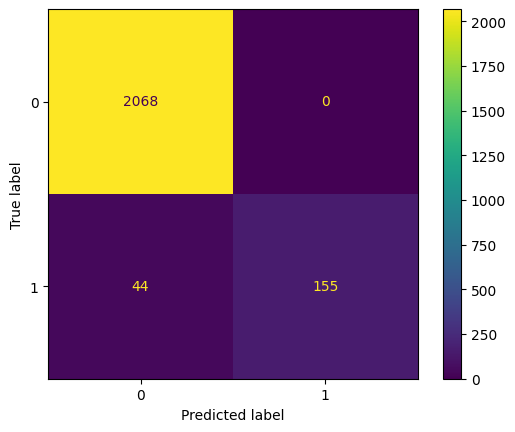

In [19]:


# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()

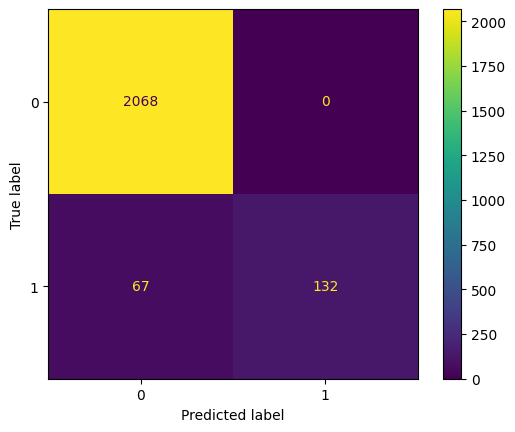

In [17]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()

In [20]:
import joblib

# Save the full pipeline (recommended)
joblib.dump(linear_model, "logistic_regression_model.pkl")

print("Model saved successfully!")


Model saved successfully!


In [24]:
model = joblib.load("logistic_regression_model.pkl")
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['home_country','source_currency','dest_currency',...,'is_weekend', 'day_of_year','week_of_year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [27]:
model.named_steps


{'preprocess': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['amount_src', 'amount_usd', 'fee',
                                   'exchange_rate_src_to_dest', 'ip_risk_score',
                                   'account_age_days', 'device_trust_score',
                                   'chargeback_history_count',
                                   'risk_score_internal', 'txn_velocity_1h',
                                   'txn_velocity_24h', 'corridor_risk',
                                   'ip_country_missing', 'kyc_tier_missing',
                                   'device_trustScore_missing', 'year',...,
                                   'day', 'hour', 'minute', 'second', 'hour_sin',
                                   'hour_cos', 'day_of_week', 'is_weekend',
                                   'day_of_year', 'week_of_year']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='